<a href="https://colab.research.google.com/github/EdgarPrueba/Portafolio1/blob/main/NB3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 3: Decodificación de un Código Convolucional mediante Viterbi y Aprendizaje Automático

## 1. Objetivo

En este laboratorio se estudia la recuperación de información transmitida mediante un código convolucional de tasa 1/2 sobre un canal AWGN. Se compara el desempeño de un método clásico de comunicaciones, basado en el algoritmo de Viterbi, con un modelo de aprendizaje automático basado en una red neuronal MLP.

El sistema de comunicación estudiado sigue la siguiente cadena:

**bits → codificador convolucional → BPSK → canal AWGN → decodificador → bits estimados**

Se consideran tres estrategias de recuperación:

1. BPSK sin codificación, utilizada como referencia.
2. Código convolucional con decodificación mediante Viterbi.
3. Código convolucional con decodificación mediante un modelo MLP.

El desempeño se evalúa mediante la tasa de error de bit (BER) para diferentes valores de \(E_b/N_0\).

La pregunta de investigación es:

> ¿Puede un modelo de aprendizaje automático aproximar la decodificación de un código convolucional y cómo se compara su desempeño con el algoritmo clásico de Viterbi bajo diferentes niveles de ruido?



## 2. Modelo de comunicación

El código convolucional utilizado tiene una tasa:

$$
R = \frac{1}{2}
$$

y un *constraint length*:

$$
K = 7
$$

Se emplean los polinomios generadores octales:

$$
(G_1,G_2) = (133,171)_8
$$

Este código posee 64 estados en su *trellis*, calculados como:

$$
2^{K-1}=2^6=64
$$

Los bits codificados se modulan mediante BPSK, utilizando la representación:

$$
x \in \{-1,+1\}
$$

El canal considerado es AWGN, por lo que la señal recibida se modela como:

$$
y=x+n
$$

donde:

$$
n\sim\mathcal{N}(0,\sigma^2)
$$

El nivel de ruido se controla mediante \(E_b/N_0\). Al aumentar \(E_b/N_0\), la energía disponible por bit es mayor respecto a la densidad espectral de potencia del ruido, por lo que disminuye la probabilidad de error de la transmisión.

La métrica principal utilizada para evaluar el sistema será la tasa de error de bit:

$$
BER=\frac{N_{\text{bits erróneos}}}{N_{\text{bits transmitidos}}}
$$


## 3. Dataset sintético

No se utilizará un dataset externo. Los datos serán generados mediante simulación de un sistema de comunicaciones digitales.

Cada muestra se obtiene a partir de bits aleatorios que son codificados mediante el código convolucional, modulados mediante BPSK y posteriormente afectados por ruido AWGN.

Para el entrenamiento del modelo de aprendizaje automático se generan múltiples tramas utilizando diferentes valores de \(E_b/N_0\). A partir de las señales recibidas se extraen ventanas locales de 14 símbolos BPSK, correspondientes a siete etapas consecutivas del código convolucional.

Cada ventana se asocia con el bit de información que debe ser estimado por la red neuronal.

Se utiliza una semilla aleatoria fija para garantizar la reproducibilidad de los experimentos.

El objetivo es mantener una relación directa entre el modelo físico del canal y los datos utilizados por el modelo de aprendizaje automático.


## 4. Configuración y generación de los datos

En esta sección se configura el experimento y se genera el conjunto de datos sintético utilizado para entrenar el modelo de aprendizaje automático.

Primero se generan bits aleatorios y se procesan mediante un codificador convolucional de tasa \(R=1/2\) y *constraint length* \(K=7\). El codificador agrega \(K-1\) bits de terminación para regresar al estado cero.

Posteriormente, los bits codificados se transforman mediante modulación BPSK, utilizando los niveles \(+1\) y \(-1\).

La señal transmitida se utiliza como entrada de un canal AWGN para generar diferentes condiciones de \(E_b/N_0\).

Para el entrenamiento se utilizan seis niveles de \(E_b/N_0\):

$$
0,\ 2,\ 4,\ 6,\ 8,\ 10\ \text{dB}
$$

Para cada trama se extraen ventanas de 14 símbolos de la señal recibida. Estas ventanas constituyen las entradas del modelo MLP, mientras que los bits originales de información representan las etiquetas.

Se utiliza una semilla aleatoria fija para garantizar que la generación de los datos sea reproducible.


In [ ]:
# ============================================================
# Celda 1 - Configuración y generación del sistema
# ============================================================

import numpy as np
import torch
import torch.nn as nn

# Configuración reproducible
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)


# ============================================================
# Configuración de hardware
# ============================================================

# Detecta automáticamente si hay una GPU (CUDA) disponible
# para acelerar el entrenamiento del modelo de aprendizaje
# automático. Si no hay GPU, se utiliza el procesador (CPU).
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Usando dispositivo: {device}")


# ============================================================
# Parámetros del código convolucional
# ============================================================

# Constraint length del código
K = 7

# Tasa del código:
# 1 bit de información -> 2 bits codificados
RATE = 1 / 2

# Polinomios generadores en representación octal
G1 = 0o133
G2 = 0o171

# Número de estados del trellis
N_STATES = 2 ** (K - 1)


# ============================================================
# Parámetros de simulación
# ============================================================

N_BITS = 10000

# Valores de Eb/N0 utilizados en la evaluación
EBN0_DB = np.array([0, 2, 4, 6, 8, 10])


# ============================================================
# Codificador convolucional
# ============================================================

def convolutional_encode(bits):
    """
    Codificador convolucional de tasa 1/2 y K=7.

    Generadores:
        G1 = (133)_8
        G2 = (171)_8

    El estado contiene los K-1 bits anteriores.
    El nuevo bit se introduce en la posición más
    significativa del registro.

    Se agregan K-1 bits cero al final para terminar
    el trellis en el estado cero.
    """

    # --------------------------------------------------------
    # Terminación del trellis
    # --------------------------------------------------------

    bits_terminated = np.concatenate(
        [
            bits,
            np.zeros(K - 1, dtype=np.uint8)
        ]
    )

    # Estado inicial: cero
    state = 0

    encoded = []

    # --------------------------------------------------------
    # Procesamiento de cada bit
    # --------------------------------------------------------

    for bit in bits_terminated:

        # El nuevo bit entra en la posición más significativa.
        #
        # El estado contiene los K-1 bits de memoria.
        # Por tanto, el registro completo tiene K bits.
        register = (
            (int(bit) << (K - 1))
            | state
        )

        # ----------------------------------------------------
        # Generación de los dos bits codificados
        # ----------------------------------------------------

        out1 = (
            (register & G1).bit_count() % 2
        )

        out2 = (
            (register & G2).bit_count() % 2
        )

        encoded.extend(
            [out1, out2]
        )

        # ----------------------------------------------------
        # Actualización del estado
        # ----------------------------------------------------

        # Se desplaza el registro una posición.
        # El resultado contiene los K-1 bits necesarios
        # para el siguiente estado.
        state = register >> 1

    return np.array(
        encoded,
        dtype=np.uint8
    )


# ============================================================
# Modulación BPSK
# ============================================================

def bpsk_modulate(bits):
    """
    Modulación BPSK.

    Mapeo:
        0 -> +1
        1 -> -1
    """

    return 1.0 - 2.0 * bits.astype(
        np.float32
    )


# ============================================================
# Canal AWGN
# ============================================================

def add_awgn(signal, ebn0_db, rate=1.0):
    """
    Agrega ruido AWGN a una señal BPSK.

    Se considera energía por símbolo normalizada:

        Es = 1

    Para una tasa de código R:

        Eb = Es / R

    Por tanto, la varianza del ruido es:

        sigma² = 1 / (2 R Eb/N0)
    """

    # Conversión de Eb/N0 de dB a escala lineal
    ebn0_linear = 10 ** (
        ebn0_db / 10
    )

    # Varianza del ruido AWGN
    noise_variance = 1 / (
        2 * rate * ebn0_linear
    )

    # Generación del ruido gaussiano
    noise = np.sqrt(
        noise_variance
    ) * np.random.randn(
        *signal.shape
    )

    return signal + noise


# ============================================================
# Generación de bits y codificación
# ============================================================

# Generación reproducible de bits de información
bits = np.random.randint(
    0,
    2,
    size=N_BITS,
    dtype=np.uint8
)

# Codificación convolucional
coded_bits = convolutional_encode(
    bits
)

# Modulación BPSK
tx_signal = bpsk_modulate(
    coded_bits
)


# ============================================================
# Información del experimento
# ============================================================

print(
    f"Número de bits de información: {len(bits)}"
)

print(
    f"Número de bits codificados:    {len(coded_bits)}"
)

print(
    f"Tasa de código:                R = {RATE}"
)

print(
    f"Constraint length:             K = {K}"
)

print(
    f"Número de estados:             {N_STATES}"
)

print(
    f"Señal BPSK generada:           {tx_signal.shape}"
)


# ============================================================
# Ejemplo de la cadena de transmisión
# ============================================================

print("\nEjemplo:")

print(
    "Bits originales :",
    bits[:10]
)

print(
    "Bits codificados:",
    coded_bits[:20]
)

print(
    "BPSK             :",
    tx_signal[:10]
)

Usando dispositivo: cpu
Número de bits de información: 10000
Número de bits codificados:    20012
Tasa de código:                R = 0.5
Constraint length:             K = 7
Número de estados:             64
Señal BPSK generada:           (20012,)

Ejemplo:
Bits originales : [0 0 1 1 1 1 0 1 0 1]
Bits codificados: [0 0 0 0 1 1 1 0 0 1 1 0 0 1 0 1 1 1 0 1]
BPSK             : [ 1.  1.  1.  1. -1. -1. -1.  1.  1. -1.]


## 5. Decodificación mediante Viterbi

El algoritmo de Viterbi permite encontrar la secuencia de estados más probable dentro del *trellis* del código convolucional.

Para cada posible transición se calcula una métrica de rama a partir de la diferencia entre los símbolos recibidos y los símbolos BPSK esperados. En este laboratorio se utilizan decisiones *soft*, por lo que el algoritmo aprovecha directamente los valores de amplitud de la señal recibida en lugar de convertirla previamente a bits duros.

La trayectoria con menor métrica acumulada se selecciona como la secuencia estimada.

Una vez obtenida la secuencia de bits, se eliminan los \(K-1\) bits de terminación utilizados durante la codificación para regresar el codificador al estado cero.

Antes de utilizar el modelo de aprendizaje automático, se verifica el funcionamiento del decodificador mediante una prueba sin ruido y una evaluación bajo ruido. La prueba sin ruido permite comprobar que la implementación del codificador y del *trellis* de Viterbi son consistentes.


In [ ]:
# ============================================================
# CELDA 2 — Generación de datos mediante ventana deslizante
# ============================================================

# Parámetros del conjunto de entrenamiento
INFO_BITS_PER_FRAME = 32
N_TRAIN_FRAMES = 3000

TRAIN_EBN0_DB = np.array([0, 2, 4, 6, 8, 10])

# Tamaño de la ventana:
# K = 7 etapas del código × 2 símbolos codificados por etapa
WINDOW_STAGES = K
WINDOW_SYMBOLS = 2 * WINDOW_STAGES

print(f"Bits de información por frame: {INFO_BITS_PER_FRAME}")
print(f"Ventana: {WINDOW_STAGES} etapas = {WINDOW_SYMBOLS} símbolos")


def extract_bit_windows(rx_signal, n_info_bits=INFO_BITS_PER_FRAME):
    """
    Extrae una ventana de símbolos recibidos para cada bit
    de información.

    Cada ventana contiene 14 símbolos:
        7 etapas × 2 símbolos codificados.

    Para mantener el mismo tamaño de entrada en los extremos,
    la ventana se desplaza para permanecer dentro del frame.

    Parámetros
    ----------
    rx_signal : np.ndarray
        Señal BPSK recibida.

    n_info_bits : int
        Número de bits de información.

    Retorna
    -------
    X : np.ndarray
        Matriz de ventanas con forma (n_info_bits, 14).
    """

    windows = []

    half_window = WINDOW_SYMBOLS // 2

    for bit_index in range(n_info_bits):

        # Posición central aproximada del bit
        center = 2 * bit_index

        # Ventana inicial
        start = center - half_window
        end = start + WINDOW_SYMBOLS

        # Ajuste en el inicio del frame
        if start < 0:
            start = 0
            end = WINDOW_SYMBOLS

        # Ajuste en el final del frame
        if end > len(rx_signal):
            end = len(rx_signal)
            start = end - WINDOW_SYMBOLS

        window = rx_signal[start:end]

        # Verificación
        if len(window) != WINDOW_SYMBOLS:
            raise ValueError(
                f"Ventana incorrecta: se esperaban "
                f"{WINDOW_SYMBOLS} símbolos y se obtuvieron "
                f"{len(window)}."
            )

        windows.append(window)

    return np.asarray(windows, dtype=np.float32)


# ------------------------------------------------------------
# Generación del conjunto de entrenamiento
# ------------------------------------------------------------

X_train = []
y_train = []

rng_train = np.random.default_rng(SEED)

for ebn0_db in TRAIN_EBN0_DB:

    for _ in range(N_TRAIN_FRAMES):

        # Bits de información
        info_bits = rng_train.integers(
            0,
            2,
            size=INFO_BITS_PER_FRAME
        ).astype(np.int8)

        # Codificación convolucional
        coded_bits = convolutional_encode(info_bits)

        # Modulación BPSK
        tx_signal = bpsk_modulate(coded_bits)

        # Canal AWGN
        rx_signal = add_awgn(
            tx_signal,
            ebn0_db,
            rate=RATE
        )

        # Extraer una ventana por cada bit
        windows = extract_bit_windows(
            rx_signal,
            INFO_BITS_PER_FRAME
        )

        X_train.append(windows)
        y_train.append(info_bits.reshape(-1, 1))


# Convertir a arrays
X_train = np.concatenate(X_train, axis=0)
y_train = np.concatenate(y_train, axis=0)

print("\nDatos de entrenamiento generados:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"Entrada del MLP: {WINDOW_SYMBOLS} símbolos")

Bits de información por frame: 32
Ventana: 7 etapas = 14 símbolos

Datos de entrenamiento generados:
X_train: (576000, 14)
y_train: (576000, 1)
Entrada del MLP: 14 símbolos


In [ ]:
# ============================================================
# Prueba de Viterbi sin ruido
# ============================================================

rx_clean = tx_signal.copy()

decoded_clean = viterbi_decode(
    rx_clean
)

errors_clean = np.sum(
    bits != decoded_clean
)

print(
    f"Errores Viterbi sin ruido: {errors_clean}"
)

Errores Viterbi sin ruido: 0


## 6. Decodificación mediante aprendizaje automático

En esta sección se utiliza una red neuronal MLP para aproximar la tarea de decodificación del código convolucional.

El modelo recibe pequeñas ventanas de muestras BPSK afectadas por ruido y aprende a estimar el bit de información correspondiente. Cada entrada contiene 14 valores, correspondientes a siete etapas consecutivas del código convolucional.

La arquitectura utilizada es:

$$
14 \rightarrow 64 \rightarrow 64 \rightarrow 1
$$

Las dos capas ocultas utilizan funciones de activación ReLU y la salida produce un único valor asociado con la probabilidad del bit de información.

El conjunto de entrenamiento se genera mediante simulación del mismo sistema de comunicaciones utilizado para el decodificador Viterbi. Se utilizan diferentes valores de \(E_b/N_0\) para que el modelo encuentre una relación entre las observaciones recibidas y los bits transmitidos bajo diferentes niveles de ruido.

El entrenamiento utiliza la función de pérdida **BCEWithLogitsLoss** y el optimizador **Adam**.

La accuracy obtenida durante el entrenamiento se utiliza únicamente como una comprobación inicial del proceso de aprendizaje. El desempeño real del modelo se determina posteriormente utilizando datos independientes y la métrica BER.


In [ ]:
# ============================================================
# Celda 3 - MLP para decodificación local
# ============================================================

from torch.utils.data import TensorDataset, DataLoader


# ============================================================
# Parámetros del entrenamiento
# ============================================================

# Número de bits de información por trama
INFO_BITS_PER_FRAME = 32

# Número de tramas utilizadas para entrenamiento
N_TRAIN_FRAMES = 3000

# Niveles de Eb/N0 utilizados durante el entrenamiento
TRAIN_EBN0_DB = [0, 2, 4, 6, 8, 10]

# Tamaño de lote
BATCH_SIZE = 256

# Número de épocas
EPOCHS = 30

# Tasa de aprendizaje
LEARNING_RATE = 1e-3


# ============================================================
# Parámetros de la ventana
# ============================================================

# El código convolucional tiene K = 7.
#
# Cada etapa del código produce dos símbolos.
#
# Por lo tanto:
#
# 7 etapas × 2 símbolos = 14 símbolos de entrada

WINDOW_STAGES = K

WINDOW_SYMBOLS = WINDOW_STAGES * 2

INPUT_SIZE = WINDOW_SYMBOLS

OUTPUT_SIZE = 1


print("Configuración del MLP:")
print(
    f"Bits de información por trama: {INFO_BITS_PER_FRAME}"
)
print(
    f"Constraint length:              K = {K}"
)
print(
    f"Etapas de contexto:             {WINDOW_STAGES}"
)
print(
    f"Símbolos por ventana:           {WINDOW_SYMBOLS}"
)
print(
    f"Entrada del MLP:                {INPUT_SIZE}"
)
print(
    f"Salida del MLP:                 {OUTPUT_SIZE}"
)


# ============================================================
# Generación del dataset sintético
# ============================================================

def generate_mlp_dataset(
    n_frames,
    ebn0_values,
    seed=42
):
    """
    Genera un dataset sintético para entrenar el MLP.

    Cada trama sigue la cadena:

        bits de información
                ↓
        código convolucional
                ↓
              BPSK
                ↓
              AWGN
                ↓
        señal recibida

    El MLP aprende una decisión local:

        ventana de símbolos recibidos
                ↓
               MLP
                ↓
          bit de información

    Cada ventana contiene 7 etapas del código
    convolucional, equivalentes a 14 símbolos.
    """

    rng = np.random.default_rng(seed)

    X = []
    y = []

    for ebn0_db in ebn0_values:

        for _ in range(n_frames):

            # ------------------------------------------------
            # Generar bits de información
            # ------------------------------------------------

            bits_frame = rng.integers(
                0,
                2,
                size=INFO_BITS_PER_FRAME,
                dtype=np.uint8
            )


            # ------------------------------------------------
            # Codificación convolucional
            # ------------------------------------------------

            coded_bits_frame = convolutional_encode(
                bits_frame
            )


            # ------------------------------------------------
            # Modulación BPSK
            # ------------------------------------------------

            tx_frame = bpsk_modulate(
                coded_bits_frame
            )


            # ------------------------------------------------
            # Canal AWGN
            # ------------------------------------------------

            rx_frame = add_awgn(
                tx_frame,
                ebn0_db,
                rate=RATE
            )


            # ------------------------------------------------
            # Construcción de ventanas
            # ------------------------------------------------
            #
            # Cada bit de información genera dos símbolos.
            #
            # Para el bit i se toma una ventana centrada
            # aproximadamente alrededor de su posición.
            #
            # Se utilizan 7 etapas = 14 símbolos.
            #
            # Para evitar problemas en los extremos de la
            # trama, se agregan símbolos de terminación
            # ya presentes en la señal codificada.
            #
            # Las ventanas se construyen de forma que cada
            # muestra tenga exactamente WINDOW_SYMBOLS entradas.
            # ------------------------------------------------

            for bit_index in range(INFO_BITS_PER_FRAME):

                center = 2 * bit_index

                half_window = WINDOW_SYMBOLS // 2

                start = center - half_window
                end = start + WINDOW_SYMBOLS

                # --------------------------------------------
                # Ajustar ventana al inicio de la trama
                # --------------------------------------------

                if start < 0:

                    start = 0
                    end = WINDOW_SYMBOLS


                # --------------------------------------------
                # Ajustar ventana al final de la trama
                # --------------------------------------------

                if end > len(rx_frame):

                    end = len(rx_frame)
                    start = end - WINDOW_SYMBOLS


                # --------------------------------------------
                # Guardar ventana y bit objetivo
                # --------------------------------------------

                window = rx_frame[
                    start:end
                ]

                X.append(
                    window
                )

                y.append(
                    bits_frame[bit_index]
                )


    X = np.asarray(
        X,
        dtype=np.float32
    )

    y = np.asarray(
        y,
        dtype=np.float32
    ).reshape(-1, 1)


    return X, y


# ============================================================
# Dataset de entrenamiento
# ============================================================

X_train, y_train = generate_mlp_dataset(
    N_TRAIN_FRAMES,
    TRAIN_EBN0_DB,
    seed=SEED
)


print("\nDataset de entrenamiento:")
print(
    f"X_train: {X_train.shape}"
)
print(
    f"y_train: {y_train.shape}"
)


# ============================================================
# Conversión a tensores
# ============================================================

X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.float32
)


# ============================================================
# Dataset y DataLoader
# ============================================================

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)


# ============================================================
# Modelo MLP
# ============================================================

class MLPDecoder(nn.Module):

    def __init__(
        self,
        input_size,
        output_size
    ):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(
                input_size,
                64
            ),

            nn.ReLU(),

            nn.Linear(
                64,
                64
            ),

            nn.ReLU(),

            nn.Linear(
                64,
                output_size
            )
        )


    def forward(self, x):

        return self.network(x)


# ============================================================
# Inicialización del modelo
# ============================================================

model = MLPDecoder(
    input_size=INPUT_SIZE,
    output_size=OUTPUT_SIZE
).to(device)


# ============================================================
# Configuración del entrenamiento
# ============================================================

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)


# ============================================================
# Entrenamiento
# ============================================================

model.train()

for epoch in range(EPOCHS):

    total_loss = 0.0

    for X_batch, y_batch in train_loader:

        # Mover datos al dispositivo
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)


        # Limpiar gradientes
        optimizer.zero_grad()


        # Predicción
        logits = model(
            X_batch
        )


        # Función de pérdida
        loss = criterion(
            logits,
            y_batch
        )


        # Backpropagation
        loss.backward()


        # Actualizar parámetros
        optimizer.step()


        total_loss += loss.item()


    average_loss = (
        total_loss
        / len(train_loader)
    )


    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} "
        f"- Loss: {average_loss:.4f}"
    )


# ============================================================
# Evaluación sobre el conjunto de entrenamiento
# ============================================================

model.eval()

with torch.no_grad():

    X_eval = X_train_tensor.to(device)
    y_eval = y_train_tensor.to(device)

    logits = model(
        X_eval
    )

    predictions = (
        torch.sigmoid(logits) >= 0.5
    ).float()

    train_accuracy = (
        predictions == y_eval
    ).float().mean().item()


print(
    f"\nAccuracy de entrenamiento: "
    f"{train_accuracy:.4f}"
)

Configuración del MLP:
Bits de información por trama: 32
Constraint length:              K = 7
Etapas de contexto:             7
Símbolos por ventana:           14
Entrada del MLP:                14
Salida del MLP:                 1

Dataset de entrenamiento:
X_train: (576000, 14)
y_train: (576000, 1)
Epoch 01/30 - Loss: 0.6895
Epoch 02/30 - Loss: 0.6833
Epoch 03/30 - Loss: 0.6581
Epoch 04/30 - Loss: 0.6313
Epoch 05/30 - Loss: 0.6094
Epoch 06/30 - Loss: 0.5905
Epoch 07/30 - Loss: 0.5761
Epoch 08/30 - Loss: 0.5665
Epoch 09/30 - Loss: 0.5583
Epoch 10/30 - Loss: 0.5518
Epoch 11/30 - Loss: 0.5470
Epoch 12/30 - Loss: 0.5432
Epoch 13/30 - Loss: 0.5400
Epoch 14/30 - Loss: 0.5372
Epoch 15/30 - Loss: 0.5345
Epoch 16/30 - Loss: 0.5322
Epoch 17/30 - Loss: 0.5305
Epoch 18/30 - Loss: 0.5289
Epoch 19/30 - Loss: 0.5280
Epoch 20/30 - Loss: 0.5268
Epoch 21/30 - Loss: 0.5258
Epoch 22/30 - Loss: 0.5251
Epoch 23/30 - Loss: 0.5240
Epoch 24/30 - Loss: 0.5233
Epoch 25/30 - Loss: 0.5231
Epoch 26/30 - Loss: 0.

## 7. Comparación de desempeño

En esta sección se evalúan los tres esquemas de transmisión y recuperación:

* BPSK sin codificación.
* Código convolucional con decodificación mediante Viterbi.
* Código convolucional con decodificación mediante MLP.

Para cada valor de \(E_b/N_0\) se generan nuevos datos de evaluación, independientes de los utilizados durante el entrenamiento del MLP.

La métrica utilizada es la tasa de error de bit:

$$
BER=\frac{N_{\text{bits erróneos}}}{N_{\text{bits transmitidos}}}
$$

La evaluación se realiza para los siguientes valores:

$$
E_b/N_0 = 0,\ 2,\ 4,\ 6,\ 8,\ 10\ \text{dB}
$$

El resultado principal se presenta mediante una gráfica de BER en función de \(E_b/N_0\), utilizando una escala logarítmica para el eje vertical.

Esta comparación permite analizar simultáneamente el efecto físico del ruido sobre el sistema, la ganancia obtenida mediante la codificación convolucional y la capacidad del modelo de aprendizaje automático para aproximar la función de decodificación de Viterbi.

Los resultados obtenidos mediante los tres métodos se almacenan además en una tabla para facilitar su comparación cuantitativa.


In [ ]:
# ============================================================
# CELDA 4 — Evaluación BER vs Eb/N0
# ============================================================

N_EVAL_FRAMES = 200

EVAL_EBN0_DB = np.array([
    0, 2, 4, 6, 8, 10
])

rng_eval = np.random.default_rng(SEED + 1)


def mlp_decode(rx_signal):
    """
    Decodifica un frame utilizando el MLP mediante
    ventanas deslizantes de 14 símbolos.
    """

    # Extraer una ventana por cada bit
    windows = extract_bit_windows(
        rx_signal,
        INFO_BITS_PER_FRAME
    )

    # Convertir a tensor
    X = torch.tensor(
        windows,
        dtype=torch.float32,
        device=device
    )

    # Evaluación
    model.eval()

    with torch.no_grad():

        logits = model(X)

        probabilities = torch.sigmoid(logits)

        decoded_bits = (
            probabilities >= 0.5
        ).int().cpu().numpy().flatten()

    return decoded_bits


# ------------------------------------------------------------
# Arreglos para almacenar los BER
# ------------------------------------------------------------

ber_bpsk = []
ber_viterbi = []
ber_mlp = []


# ------------------------------------------------------------
# Evaluación para cada Eb/N0
# ------------------------------------------------------------

for ebn0_db in EVAL_EBN0_DB:

    errors_bpsk = 0
    errors_viterbi = 0
    errors_mlp = 0

    total_bits = 0

    for _ in range(N_EVAL_FRAMES):

        # ----------------------------------------------------
        # Bits originales
        # ----------------------------------------------------

        info_bits = rng_eval.integers(
            0,
            2,
            size=INFO_BITS_PER_FRAME
        ).astype(np.int8)


        # ====================================================
        # 1. BPSK SIN CODIFICACIÓN
        # ====================================================

        tx_bpsk = bpsk_modulate(info_bits)

        rx_bpsk = add_awgn(
            tx_bpsk,
            ebn0_db,
            rate=1.0
        )

        decoded_bpsk = (
            rx_bpsk < 0
        ).astype(np.int8)

        errors_bpsk += np.sum(
            decoded_bpsk != info_bits
        )


        # ====================================================
        # 2. CÓDIGO CONVOLUCIONAL + VITERBI
        # ====================================================

        coded_bits = convolutional_encode(
            info_bits
        )

        tx_coded = bpsk_modulate(
            coded_bits
        )

        rx_coded = add_awgn(
            tx_coded,
            ebn0_db,
            rate=RATE
        )

        decoded_viterbi = viterbi_decode(
            rx_coded
        )

        errors_viterbi += np.sum(
            decoded_viterbi != info_bits
        )


        # ====================================================
        # 3. CÓDIGO CONVOLUCIONAL + MLP
        # ====================================================

        decoded_mlp = mlp_decode(
            rx_coded
        )

        errors_mlp += np.sum(
            decoded_mlp != info_bits
        )


        total_bits += INFO_BITS_PER_FRAME


    # --------------------------------------------------------
    # Calcular BER
    # --------------------------------------------------------

    ber_bpsk.append(
        errors_bpsk / total_bits
    )

    ber_viterbi.append(
        errors_viterbi / total_bits
    )

    ber_mlp.append(
        errors_mlp / total_bits
    )


# ------------------------------------------------------------
# Convertir a NumPy
# ------------------------------------------------------------

ber_bpsk = np.asarray(ber_bpsk)
ber_viterbi = np.asarray(ber_viterbi)
ber_mlp = np.asarray(ber_mlp)


# ------------------------------------------------------------
# Mostrar resultados
# ------------------------------------------------------------

print("\nResultados BER")
print("-" * 65)

for i, ebn0_db in enumerate(EVAL_EBN0_DB):

    print(
        f"Eb/N0 = {ebn0_db:2d} dB | "
        f"BPSK = {ber_bpsk[i]:.6f} | "
        f"Viterbi = {ber_viterbi[i]:.6f} | "
        f"MLP = {ber_mlp[i]:.6f}"
    )


Resultados BER
-----------------------------------------------------------------
Eb/N0 =  0 dB | BPSK = 0.072188 | Viterbi = 0.066875 | MLP = 0.468750
Eb/N0 =  2 dB | BPSK = 0.040313 | Viterbi = 0.000313 | MLP = 0.437969
Eb/N0 =  4 dB | BPSK = 0.011562 | Viterbi = 0.000000 | MLP = 0.340313
Eb/N0 =  6 dB | BPSK = 0.001563 | Viterbi = 0.000000 | MLP = 0.230937
Eb/N0 =  8 dB | BPSK = 0.000313 | Viterbi = 0.000000 | MLP = 0.125625
Eb/N0 = 10 dB | BPSK = 0.000000 | Viterbi = 0.000000 | MLP = 0.073906


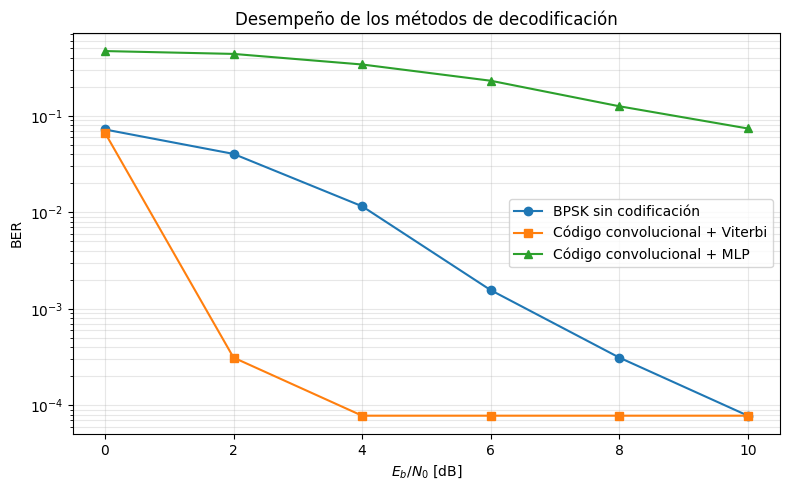

In [ ]:
# ============================================================
# FIGURA 1 — BER vs Eb/N0
# ============================================================

import matplotlib.pyplot as plt

# Para visualizar valores BER = 0 en escala logarítmica,
# se utiliza un piso únicamente para la gráfica.
total_eval_bits = N_EVAL_FRAMES * INFO_BITS_PER_FRAME

ber_floor = 0.5 / total_eval_bits

ber_bpsk_plot = np.where(
    ber_bpsk == 0,
    ber_floor,
    ber_bpsk
)

ber_viterbi_plot = np.where(
    ber_viterbi == 0,
    ber_floor,
    ber_viterbi
)

ber_mlp_plot = np.where(
    ber_mlp == 0,
    ber_floor,
    ber_mlp
)


plt.figure(figsize=(8, 5))

plt.semilogy(
    EVAL_EBN0_DB,
    ber_bpsk_plot,
    marker="o",
    label="BPSK sin codificación"
)

plt.semilogy(
    EVAL_EBN0_DB,
    ber_viterbi_plot,
    marker="s",
    label="Código convolucional + Viterbi"
)

plt.semilogy(
    EVAL_EBN0_DB,
    ber_mlp_plot,
    marker="^",
    label="Código convolucional + MLP"
)

plt.xlabel(r"$E_b/N_0$ [dB]")
plt.ylabel("BER")
plt.title("Desempeño de los métodos de decodificación")
plt.grid(True, which="both", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## 8. Análisis físico y discusión de resultados

La curva BER vs \(E_b/N_0\) permite observar la relación entre la calidad del canal y la probabilidad de recuperar incorrectamente los bits transmitidos.

Al aumentar \(E_b/N_0\), la energía disponible por bit aumenta en relación con el ruido del canal. Como consecuencia, las muestras recibidas presentan una menor dispersión alrededor de los valores ideales de BPSK, \(+1\) y \(-1\), y el BER tiende a disminuir.

En el sistema BPSK sin codificación se observa esta tendencia: el BER disminuye desde aproximadamente 0.072 a 0 dB hasta 0 en las muestras evaluadas a 10 dB. Esto representa el comportamiento esperado de una transmisión BPSK sobre un canal AWGN.

La comparación con el código convolucional permite observar el efecto de la codificación de canal. El algoritmo de Viterbi utiliza explícitamente la estructura del *trellis* para encontrar una secuencia de bits coherente con las observaciones recibidas. En los resultados obtenidos, Viterbi presenta un BER considerablemente menor que BPSK sin codificación, alcanzando un BER observado de 0 a partir de 4 dB en las muestras evaluadas.

El MLP también presenta una mejora conforme aumenta \(E_b/N_0\). Su BER disminuye aproximadamente de 0.469 a 0 dB hasta 0.074 a 10 dB. Sin embargo, su desempeño permanece por debajo del obtenido mediante Viterbi.

Este resultado no representa un fallo del experimento. Por el contrario, permite evidenciar una diferencia fundamental entre ambos enfoques: Viterbi incorpora explícitamente el conocimiento estructural del código convolucional, mientras que el MLP debe aprender la relación entre las observaciones recibidas y los bits transmitidos a partir de ejemplos.

Por tanto, el experimento muestra que el modelo de aprendizaje automático es capaz de aprender parcialmente la relación entre la señal recibida y los bits originales, ya que su BER disminuye consistentemente al mejorar las condiciones del canal. Sin embargo, bajo la configuración utilizada, no logra aproximar con la misma precisión al decodificador Viterbi.

Finalmente, también existe una diferencia en la forma de procesamiento. Viterbi no requiere una etapa de entrenamiento, pero realiza un procesamiento basado en el *trellis* del código. El MLP requiere una etapa previa de entrenamiento y almacenamiento de sus parámetros, mientras que su inferencia posterior consiste principalmente en operaciones matriciales que pueden ejecutarse de forma eficiente una vez entrenado.


## 9. Visualización del efecto del canal AWGN

Para complementar la curva BER vs \(E_b/N_0\), se visualiza directamente el efecto del ruido sobre la señal BPSK transmitida.

La señal BPSK ideal está formada por los valores \(+1\) y \(-1\). Al atravesar el canal AWGN, estos valores se modifican debido a la componente aleatoria de ruido:

$$
y=x+n
$$

La representación de las muestras recibidas permite observar físicamente cómo el ruido modifica los símbolos transmitidos.

Para un valor bajo de \(E_b/N_0\), como 0 dB, las muestras presentan una mayor dispersión alrededor de los valores ideales \(+1\) y \(-1\). Esto aumenta la probabilidad de que una muestra cruce la región de decisión y sea interpretada como el símbolo contrario.

Al aumentar \(E_b/N_0\), como en el caso de 10 dB, la dispersión de las muestras disminuye y las dos regiones asociadas con los símbolos BPSK se vuelven más diferenciadas.

Esta visualización complementa la interpretación de la curva BER, ya que permite relacionar directamente el comportamiento físico del canal AWGN con el desempeño observado durante la recuperación de los bits.


Verificación de la señal BPSK y el canal AWGN
------------------------------------------------------------
Número de símbolos visualizados: 300

Señal transmitida:
Media: -0.0067
Desviación estándar: 1.0000
Primeros 10 símbolos: [-1. -1.  1. -1.  1.  1. -1.  1.  1.  1.]

Canal AWGN - Eb/N0 = 0 dB:
Media recibida: 0.0359
Desviación estándar: 1.4799
Mínimo: -4.0333
Máximo: 3.3626
Primeros 10 símbolos: [-0.00614113  0.86748716  2.3734684  -1.80356118  0.84452778 -0.0897744
 -0.02358392 -0.35525242  0.12411557  0.75699272]

Canal AWGN - Eb/N0 = 10 dB:
Media recibida: 0.0040
Desviación estándar: 1.0786
Mínimo: -1.8866
Máximo: 1.7097
Primeros 10 símbolos: [-1.57791429 -1.28608777  1.21674838 -0.92979327  0.59868104  1.14607589
 -0.47120281  0.9059367   1.07420235  0.55043976]


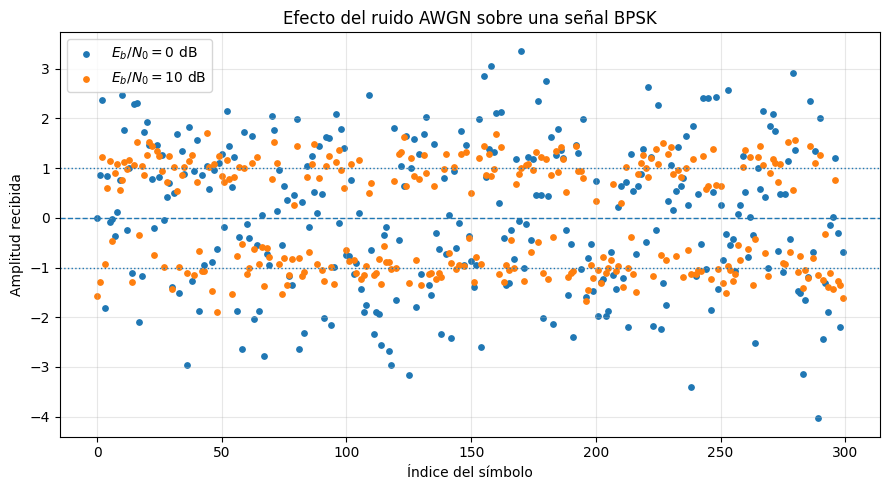

In [ ]:
# ============================================================
# Celda 5 - Efecto del canal AWGN sobre BPSK
# ============================================================

import matplotlib.pyplot as plt

# Número de símbolos que se visualizarán
N_SYMBOLS_PLOT = 300

# ------------------------------------------------------------
# Generar una señal de prueba
# ------------------------------------------------------------

rng_plot = np.random.default_rng(SEED + 2)

bits_plot = rng_plot.integers(
    0,
    2,
    size=200
).astype(np.int8)

coded_bits_plot = convolutional_encode(bits_plot)

tx_signal_plot = bpsk_modulate(coded_bits_plot)

# Tomar una sección de la señal transmitida
tx_plot = tx_signal_plot[:N_SYMBOLS_PLOT]

# Dos niveles de Eb/N0 para comparar
EBN0_LOW = 0
EBN0_HIGH = 10

# ------------------------------------------------------------
# Generar señales recibidas
# ------------------------------------------------------------

rx_low = add_awgn(
    tx_plot,
    EBN0_LOW,
    RATE
)

rx_high = add_awgn(
    tx_plot,
    EBN0_HIGH,
    RATE
)


# ============================================================
# Salidas de verificación
# ============================================================

print("Verificación de la señal BPSK y el canal AWGN")
print("-" * 60)

print(f"Número de símbolos visualizados: {len(tx_plot)}")

print("\nSeñal transmitida:")
print(f"Media: {np.mean(tx_plot):.4f}")
print(f"Desviación estándar: {np.std(tx_plot):.4f}")
print(f"Primeros 10 símbolos: {tx_plot[:10]}")

print("\nCanal AWGN - Eb/N0 = 0 dB:")
print(f"Media recibida: {np.mean(rx_low):.4f}")
print(f"Desviación estándar: {np.std(rx_low):.4f}")
print(f"Mínimo: {np.min(rx_low):.4f}")
print(f"Máximo: {np.max(rx_low):.4f}")
print(f"Primeros 10 símbolos: {rx_low[:10]}")

print("\nCanal AWGN - Eb/N0 = 10 dB:")
print(f"Media recibida: {np.mean(rx_high):.4f}")
print(f"Desviación estándar: {np.std(rx_high):.4f}")
print(f"Mínimo: {np.min(rx_high):.4f}")
print(f"Máximo: {np.max(rx_high):.4f}")
print(f"Primeros 10 símbolos: {rx_high[:10]}")


# ============================================================
# Visualización
# ============================================================

plt.figure(figsize=(9, 5))

plt.scatter(
    np.arange(N_SYMBOLS_PLOT),
    rx_low,
    s=15,
    label=r"$E_b/N_0 = 0$ dB"
)

plt.scatter(
    np.arange(N_SYMBOLS_PLOT),
    rx_high,
    s=15,
    label=r"$E_b/N_0 = 10$ dB"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.axhline(
    1,
    linestyle=":",
    linewidth=1
)

plt.axhline(
    -1,
    linestyle=":",
    linewidth=1
)

plt.xlabel("Índice del símbolo")
plt.ylabel("Amplitud recibida")
plt.title("Efecto del ruido AWGN sobre una señal BPSK")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Celda 6 - Tabla final de resultados BER
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# Crear tabla de resultados
# ------------------------------------------------------------

results_df = pd.DataFrame({
    "Eb/N0 (dB)": EVAL_EBN0_DB,
    "BER - BPSK": ber_bpsk,
    "BER - Viterbi": ber_viterbi,
    "BER - MLP": ber_mlp
})

# ------------------------------------------------------------
# Mostrar tabla
# ------------------------------------------------------------

print("Tabla final de resultados BER")
print("-" * 70)

display(
    results_df.style.format({
        "BER - BPSK": "{:.6f}",
        "BER - Viterbi": "{:.6f}",
        "BER - MLP": "{:.6f}"
    })
)

# ------------------------------------------------------------
# Guardar resultados
# ------------------------------------------------------------

RESULTS_FILE = "nb3_ber_results.csv"

results_df.to_csv(
    RESULTS_FILE,
    index=False
)

print(f"\nResultados guardados en: {RESULTS_FILE}")

Tabla final de resultados BER
----------------------------------------------------------------------


,Eb/N0 (dB),BER - BPSK,BER - Viterbi,BER - MLP
0,0,0.072188,0.066875,0.468750
1,2,0.040313,0.000313,0.437969
2,4,0.011562,0.000000,0.340313
3,6,0.001563,0.000000,0.230937
4,8,0.000313,0.000000,0.125625
5,10,0.000000,0.000000,0.073906



Resultados guardados en: nb3_ber_results.csv
